# 🏜️ Drought EDA
## Analysis of soil moisture and precipitation

This notebook is part of the Disaster Prediction System MCA Project.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import os

# 1. Correct Path
DATA_PATH = r'C:\Users\adity\OneDrive\Desktop\disaster\data'

# 2. Join path with filename
drought_file = os.path.join(DATA_PATH, 'drought.csv')

# 3. Read the data
df = pd.read_csv(drought_file)

# 4. Verify it worked
print("Data loaded successfully!")
display(df.head())

Data loaded successfully!


,location,precipitation,temperature,soil_moisture,evapotranspiration,spi_3month,spi_6month,vegetation_index,month,year,region_id,drought_risk,drought_severity
0,Bundelkhand,150,38,12,7.2,-2.1,-1.8,0.35,5,2023,1,1,2
1,Marathwada,45,42,8,8.1,-1.6,-1.4,0.28,6,2022,2,1,1
2,Eastern Tamil Nadu,250,35,18,6.5,-0.8,-0.9,0.52,7,2023,3,0,0
3,Bundelkhand,35,44,6,8.5,-2.3,-2.0,0.22,8,2021,1,1,3
4,Other Region,180,37,15,7.0,-1.2,-1.1,0.42,9,2022,4,0,0


### Drought Severity Correlation

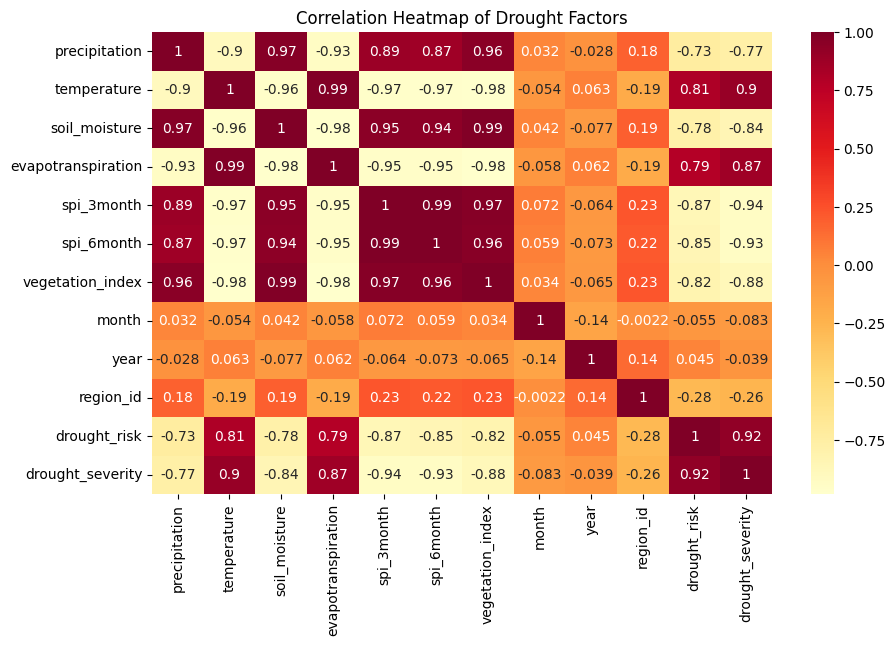

In [4]:
plt.figure(figsize=(10,6))
# Select only numeric columns to avoid errors
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='YlOrRd')
plt.title('Correlation Heatmap of Drought Factors')
plt.show()

Preprocessing

C:\Users\adity\AppData\Local\Temp\ipykernel_2840\3802870261.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='drought_severity', data=df, palette='viridis')


Drought Model Accuracy - Random Forest: 0.90


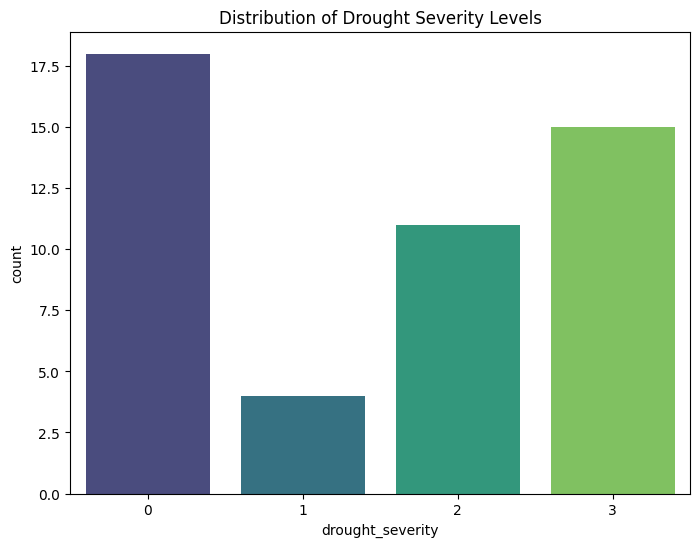

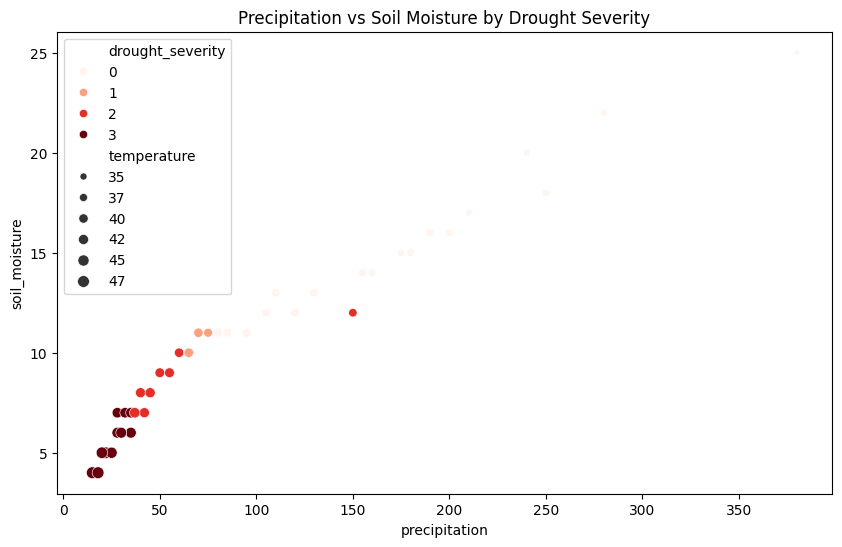

In [5]:
# Preprocessing
X_dr = df[['precipitation', 'temperature', 'soil_moisture', 'evapotranspiration', 'spi_3month', 'spi_6month', 'vegetation_index']]
y_dr = df['drought_severity']

X_train_dr, X_test_dr, y_train_dr, y_test_dr = train_test_split(X_dr, y_dr, test_size=0.2, random_state=42)

# Model 1: Random Forest
rf_dr = RandomForestClassifier(n_estimators=100, random_state=42)
rf_dr.fit(X_train_dr, y_train_dr)
y_pred_rf_dr = rf_dr.predict(X_test_dr)
acc_rf_dr = accuracy_score(y_test_dr, y_pred_rf_dr)

# Visualization: Severity Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='drought_severity', data=df, palette='viridis')
plt.title('Distribution of Drought Severity Levels')
plt.savefig('drought_severity_dist.png')

# Visualization: Precipitation vs Soil Moisture colored by severity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='precipitation', y='soil_moisture', hue='drought_severity', palette='Reds', size='temperature')
plt.title('Precipitation vs Soil Moisture by Drought Severity')
plt.savefig('drought_scatter.png')

print(f"Drought Model Accuracy - Random Forest: {acc_rf_dr:.2f}")

# Visualization

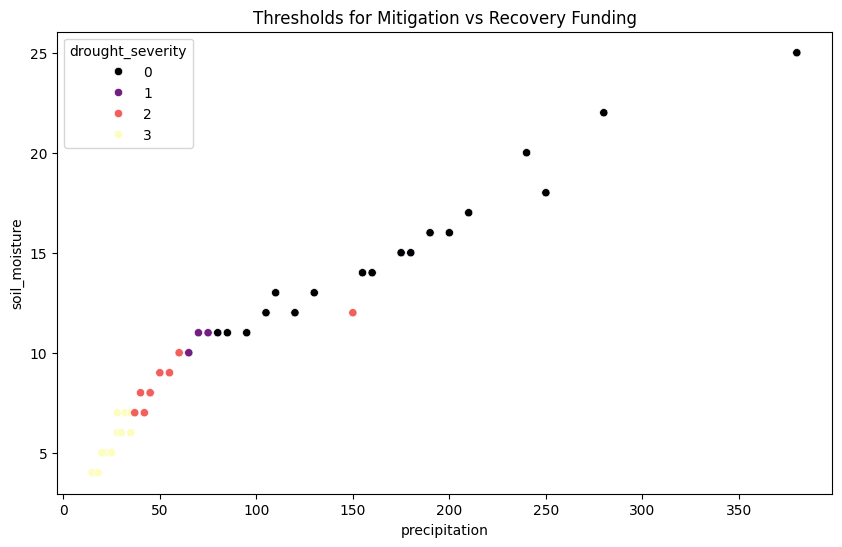

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='precipitation', y='soil_moisture', hue='drought_severity', palette='magma')
plt.title('Thresholds for Mitigation vs Recovery Funding')
plt.show()

# Model: Predicting Severity for Budget Allocation
X = df[['precipitation', 'temperature', 'soil_moisture', 'evapotranspiration', 'spi_3month']]
y = df['drought_severity']
model = RandomForestClassifier(n_estimators=100).fit(X, y)